### Step 1: Importing all the libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

pd.set_option('display.max_columns', None)

### Step 2: Data Collection

Loading the same earthquake catalogue used across the group's report, using the same file name and path convention (`Earthquake.csv`) as the rest of the team's notebooks so everything stays consistent when merged.

In [ ]:

df = pd.read_csv("Earthquake.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nEvent type counts:")
print(df["type"].value_counts())

Dataset shape: (17100, 22)

First 5 rows:
                       time  latitude  longitude    depth  mag magType    nst  \
0  2026-05-30T21:15:59.807Z   38.3564    73.8219  131.794  4.9      mb   80.0   
1  2026-05-29T12:22:54.128Z   23.4621    93.7220   57.374  4.3      mb   32.0   
2  2026-05-28T02:37:50.460Z   33.1393    96.1517   10.000  4.7      mb  111.0   
3  2026-05-26T16:30:57.714Z   23.1849    94.5425  102.712  4.3      mb   21.0   
4  2026-05-26T14:07:51.354Z   23.7982    94.8304  112.776  4.5      mb   36.0   

     gap   dmin   rms net          id                   updated  \
0   78.0  1.052  0.94  us  us7000spkb  2026-05-30T21:35:21.040Z   
1  126.0  2.503  0.68  us  us7000sp9a  2026-05-29T12:58:49.040Z   
2   47.0  5.492  0.73  us  us7000snzw  2026-05-28T05:26:32.040Z   
3  158.0  2.000  0.43  us  us7000sntk  2026-05-27T14:59:41.040Z   
4   68.0  2.581  0.40  us  us6000t08d  2026-05-26T17:07:05.040Z   

                                   place        type  horizontalErro

### Step 3: Preprocessing

Following the module's required pipeline order (Data Collection -> Preprocessing -> Feature Engineering -> Model Training).

**3.1 Remove non-earthquake events.** The raw catalogue includes 3 "nuclear explosion" records picked up by the same seismic network. These are removed before training a model about earthquake severity.

**3.2 Handle missing values.** As with our team's Decision Tree, several instrumentation-quality columns have a large number of missing values. We impute with the column median, which is robust to outliers, rather than dropping the majority of rows.

In [ ]:
print("Rows before filtering to earthquakes only:", df.shape[0])
df = df[df["type"] == "earthquake"].copy()
print("Rows after removing non-earthquake events (e.g. nuclear explosions):", df.shape[0])

feature_cols = ["latitude", "longitude", "depth", "gap", "dmin", "rms", "nst", "horizontalError", "depthError"]

print("\nMissing values in candidate features:")
print(df[feature_cols].isnull().sum())

X = df[feature_cols].copy()
for col in feature_cols:
    X[col] = X[col].fillna(X[col].median())

print("\nMissing values after imputation:", X.isnull().sum().sum())

Rows before filtering to earthquakes only: 17100
Rows after removing non-earthquake events (e.g. nuclear explosions): 17097

Missing values in candidate features:
latitude               0
longitude              0
depth                  0
gap                 6655
dmin               10861
rms                  256
nst                 9878
horizontalError    11345
depthError          6902
dtype: int64

Missing values after imputation: 0


### Step 4: Feature Engineering

**Target variable** We deliberately reuse the exact same bins and labels used for Decision Tree, so that the two models can be fairly compared in Section 5 of the group report. Using a different target definition here would make any accuracy comparison meaningless.

In [ ]:
bins = [0, 4.5, 5.5, 10]
labels = ["Light", "Moderate", "Strong"]
df["Risk_class"] = pd.cut(df["mag"], bins=bins, labels=labels)

print("Risk class distribution:")
print(df["Risk_class"].value_counts())

y = df["Risk_class"]
y.name = "Risk_class" # Explicitly set the series name

# Defensive check: drop any rows where the target could not be computed.
mask = y.notna()
X, y = X.loc[mask], y[mask]

print("\nFinal feature matrix shape:", X.shape)
print("Final target vector shape:", y.shape)

Risk class distribution:
Risk_class
Light       9574
Moderate    7036
Strong       487
Name: count, dtype: int64

Final feature matrix shape: (17097, 9)
Final target vector shape: (17097,)


### Step 5: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("\nClass balance preserved in test set:")
print(y_test.value_counts(normalize=True).round(3))

Train size: (13677, 9)  Test size: (3420, 9)

Class balance preserved in test set:
severity_class
Light       0.560
Moderate    0.412
Strong      0.028
Name: proportion, dtype: float64


### Step 6: Hyperparameter Choice

Rather than hardcoding values with no explanation, we briefly compare a small grid of `n_estimators` / `max_depth` combinations using out-of-bag (OOB) accuracy, which RandomForestClassifier can compute for free from the samples left out of each tree's bootstrap sample, without needing a separate validation split.

In [ ]:
candidate_grid = [
    {"n_estimators": 100, "max_depth": 8},
    {"n_estimators": 100, "max_depth": 15},
    {"n_estimators": 200, "max_depth": 15},
]

print("Comparing candidate hyperparameters using out-of-bag (OOB) accuracy:\n")
best_oob = -1
best_params = None
for params in candidate_grid:
    trial_model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        class_weight="balanced",
        oob_score=True,
        random_state=42,
    )
    trial_model.fit(X_train, y_train)
    print(f"n_estimators={params['n_estimators']:>3}, max_depth={params['max_depth']:>3}  ->  OOB accuracy = {trial_model.oob_score_:.4f}")
    if trial_model.oob_score_ > best_oob:
        best_oob = trial_model.oob_score_
        best_params = params

print(f"\nBest configuration: {best_params} (OOB accuracy = {best_oob:.4f})")
best_n_estimators = best_params["n_estimators"]
best_max_depth = best_params["max_depth"]

Comparing candidate hyperparameters using out-of-bag (OOB) accuracy:

n_estimators=100, max_depth=  8  ->  OOB accuracy = 0.6338
n_estimators=100, max_depth= 15  ->  OOB accuracy = 0.7085
n_estimators=200, max_depth= 15  ->  OOB accuracy = 0.7095

Best configuration: {'n_estimators': 200, 'max_depth': 15} (OOB accuracy = 0.7095)


### Step 7: Model Training

Hyperparameter choices, and why each one was made:

- `n_estimators`, `max_depth` 
- `class_weight="balanced"`

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    class_weight="balanced",
    random_state=42,
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print("Model trained with", best_n_estimators, "trees. Predictions generated for", len(y_pred), "test samples.")

Model trained with 200 trees. Predictions generated for 3420 test samples.


### Step 8: Evaluation Metrics

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("=== Random Forest Performance ===")
print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision (wtd)   : {precision:.4f}")
print(f"Recall (wtd)      : {recall:.4f}")
print(f"F1-score (wtd)    : {f1:.4f}")

print("\nFull per-class classification report:")
print(classification_report(y_test, y_pred, zero_division=0))

=== Random Forest Performance ===
Accuracy          : 0.7012
Precision (wtd)   : 0.7096
Recall (wtd)      : 0.7012
F1-score (wtd)    : 0.7045

Full per-class classification report:
              precision    recall  f1-score   support

       Light       0.78      0.75      0.76      1915
    Moderate       0.64      0.65      0.65      1408
      Strong       0.32      0.52      0.40        97

    accuracy                           0.70      3420
   macro avg       0.58      0.64      0.60      3420
weighted avg       0.71      0.70      0.70      3420



### Step 9: Confusion Matrix

Confusion Matrix (rows = actual, columns = predicted):
          Light  Moderate  Strong
Light      1427       463      25
Moderate    408       921      79
Strong        1        46      50


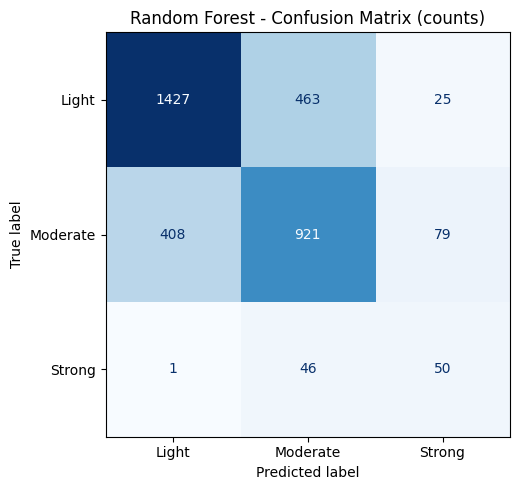

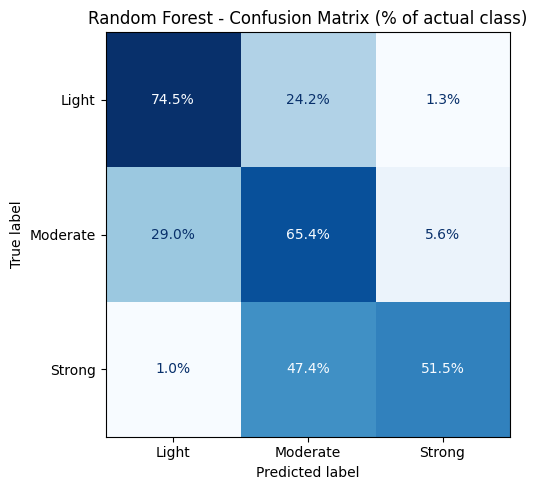

In [ ]:
labels = ["Light", "Moderate", "Strong"]

cm = confusion_matrix(y_test, y_pred, labels=labels)
print("Confusion Matrix (rows = actual, columns = predicted):")
print(pd.DataFrame(cm, index=labels, columns=labels))

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Random Forest - Confusion Matrix (counts)")
plt.tight_layout()
plt.savefig("random_forest_confusion_matrix.png", dpi=150)
plt.show()

cm_pct = confusion_matrix(y_test, y_pred, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(6, 5))
disp_pct = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=labels)
disp_pct.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".1%")
plt.title("Random Forest - Confusion Matrix (% of actual class)")
plt.tight_layout()
plt.savefig("random_forest_confusion_matrix_pct.png", dpi=150)
plt.show()

### Step 10: Feature Importance

Unlike a single Decision Tree, this ranking is averaged across all trees in the forest, making it a more robust estimate of which features actually matter.

        Feature  Importance
            gap    0.249677
            nst    0.194946
          depth    0.108207
     depthError    0.104266
            rms    0.097143
       latitude    0.085137
      longitude    0.082879
           dmin    0.040798
horizontalError    0.036948


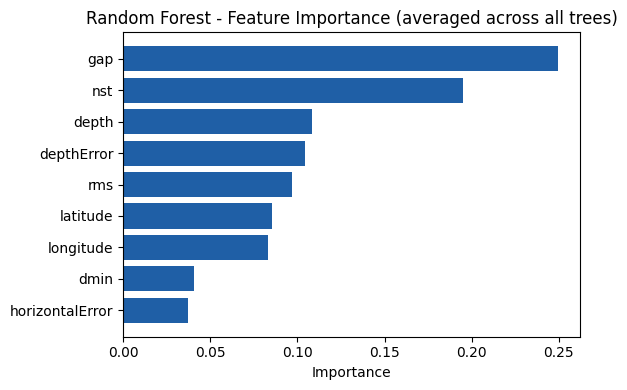

In [ ]:
importances = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_model.feature_importances_,
}).sort_values("Importance", ascending=False)

print(importances.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(importances["Feature"], importances["Importance"], color="#1f5fa6")
ax.invert_yaxis()
ax.set_xlabel("Importance")
ax.set_title("Random Forest - Feature Importance (averaged across all trees)")
plt.tight_layout()
plt.savefig("random_forest_feature_importance.png", dpi=150)
plt.show()

### Step 12: Save Metrics

In [ ]:
results = pd.DataFrame([{
    "Model": "Random Forest",
    "Accuracy": round(accuracy, 4),
    "Precision (weighted)": round(precision, 4),
    "Recall (weighted)": round(recall, 4),
    "F1-score (weighted)": round(f1, 4),
}])
print(results)

Saved metrics table to random_forest_results.csv
           Model  Accuracy  Precision (weighted)  Recall (weighted)  \
0  Random Forest    0.7012                0.7096             0.7012   

   F1-score (weighted)  
0               0.7045  

=== RANDOM FOREST CLASSIFICATION COMPLETE ===


### Step 13: Prediction on New Examples

Now, let's demonstrate how to use the trained Random Forest model (`rf_model`) to predict the Risk class for new, unseen earthquake examples. We'll create some hypothetical new data points that follow the same feature structure as our training data.

In [ ]:
import pandas as pd

# Create some new hypothetical earthquake examples
# The features should be in the same order as 'feature_cols':
# ['latitude', 'longitude', 'depth', 'gap', 'dmin', 'rms', 'nst', 'horizontalError', 'depthError']

new_data = pd.DataFrame({
    'latitude': [30.0, 25.0, 35.0],
    'longitude': [85.0, 90.0, 75.0],
    'depth': [10.0, 150.0, 50.0],
    'gap': [100.0, 50.0, 200.0],
    'dmin': [0.5, 2.0, 1.0],
    'rms': [0.2, 0.8, 0.5],
    'nst': [50.0, 100.0, 30.0],
    'horizontalError': [5.0, 15.0, 8.0],
    'depthError': [3.0, 10.0, 5.0]
})

print("New examples to predict:")
display(new_data)

# Make predictions using the trained model
new_predictions = rf_model.predict(new_data)

print("\nPredicted Risk classes for new examples:")
for i, pred in enumerate(new_predictions):
    print(f"Example {i+1}: {pred}")

New examples to predict:


,latitude,longitude,depth,gap,dmin,rms,nst,horizontalError,depthError
0,30.0,85.0,10.0,100.0,0.5,0.2,50.0,5.0,3.0
1,25.0,90.0,150.0,50.0,2.0,0.8,100.0,15.0,10.0
2,35.0,75.0,50.0,200.0,1.0,0.5,30.0,8.0,5.0



Predicted Risk classes for new examples:
Example 1: Light
Example 2: Moderate
Example 3: Light
